# **O Modelo GPT**
<font size=3>

Nas aulas anteriores, desenvolvemos a estrutura do modelo **Transformer** original e exploramos o poder da representação bidirecional do **BERT**. Agora, seguiremos para a tarefa de **geração de texto**. Nesta aula, exploraremos a família de modelos que redefiniu os limites da Inteligência Artificial moderna: o **GPT** (*Generative Pre-trained Transformer*). Deixaremos de lado o *Encoder* para nos concentrarmos exclusivamente em uma arquitetura ***Decoder-only***. Ao longo deste notebook, construiremos do zero, utilizando **Keras**, a arquitetura motordos Grandes Modelos de Linguagem (LLMs) atuais.

<font size=3><center>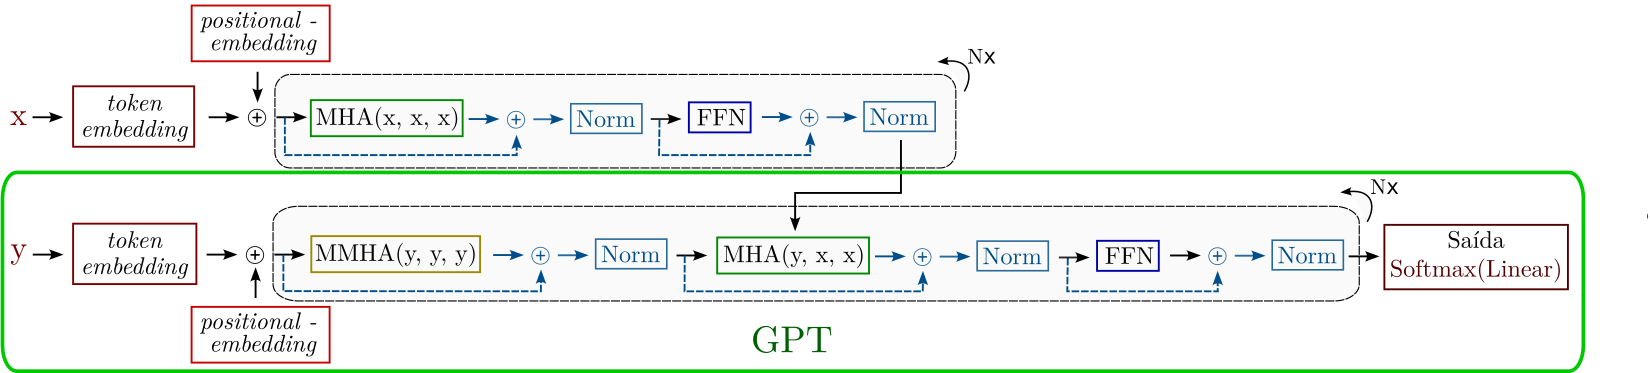</center></p><p style="text-align:center;"><em>GPT: Transformer decoder.</em>

## **1. Introdução:**
<font size=3>

Em junho de 2018, pesquisadores da **OpenAI** publicaram o artigo pioneiro: [*Improving Language Understanding by Generative Pre-Training*](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf). Este trabalho introduziu o primeiro **GPT** (posteriormente batizado de **GPT-1**).

### **1.1 O modelo GPT-1:**
<font size=3>

A grande intuição deste artigo foi demonstrar que, ao descartar completamente o *Encoder* do Transformer e empilhar apenas blocos de **Decoder**, era possível criar um modelo de linguagem altamente genérico através de um processo em duas etapas:
1. **Pré-treinamento não-supervisionado:** Treinar o modelo em um volume massivo de texto bruto para prever a próxima palavra, forçando a rede a capturar a estrutura gramatical, semântica e fatos sobre o mundo.

2. **Ajuste fino supervisionado:** Adaptar esse modelo pré-treinado para tarefas específicas usando poucos dados rotulados.
   > **Observação:** No GPT-1, isso incluía tarefas de classificação de texto ou análise de sentimento. Os pesquisadores cortavam a camada de saída generativa e adicionavam uma camada de classificação no topo. Foi só a partir do GPT-2 que a equipe percebeu que o modelo podia classificar coisas apenas gerando texto através de *prompts*, sem precisar alterar seus pesos.

Com apenas **117 milhões de parâmetros**, o GPT-1 serviu como uma prova de conceito de que arquiteturas *decoder-only* eram viáveis e escaláveis.

### **1.2 O Salto de Escala e a Emergência do GPT-2**
<font size=3>

Um ano depois, em 2019, a equipe de pesquisadores expandiu o modelo com o lançamento do **GPT-2** no artigo [*Language Models are Unsupervised Multitask Learners*](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf). Escalado para **1.5 bilhão de parâmetros**, o GPT-2 consolidou um novo paradigma: a inferência ***Zero-Shot*** e o ***In-Context Learning***. Os pesquisadores provaram que, se o modelo de linguagem for suficientemente grande e treinado em dados diversificados, ele não precisa de *fine-tuning* para tarefas específicas; ele aprende a realizar tarefas de forma orgânica, interpretando as instruções diretamente no texto de entrada (*prompt*).

Para que o modelo conseguisse saltar de 117 milhões para 1.5 bilhão de parâmetros, a arquitetura precisaria evoluir. Se simplesmente aumentassem o GPT-1, o treinamento colapsaria devido à instabilidade dos gradientes. Três aprimoramentos foram feitos no GPT-2:

* **Mudança para _Pre-Layer Normalization_ (Pre-LN):** O GPT-1 utilizava *Post-LN* (idêntico ao Transformer original), onde a normalização de camada ocorria *depois* das somas residuais. O GPT-2 inverteu isso, movendo a *Layer Normalization* para a **entrada** de cada subcamada (antes da atenção e do feed-forward). Isso limpou o caminho do gradiente durante o *backpropagation*, permitindo redes muito mais profundas. Uma camada extra de normalização também foi adicionada após o último bloco estrutural.

* **Expansão da janela de contexto:** A capacidade de memória do modelo saltou de **512 tokens** (GPT-1) para **1024 tokens** (GPT-2), permitindo a geração de textos longos e coerentes.

* **Tokenização via _Byte-level_:** O GPT-2 reformulou o algoritmo *Byte Pair Encoding* para operar a nível de *bytes* em vez de caracteres/subpalavras puros. Isso eliminou o problema de tokens desconhecidos (`[UNK]`), permitindo que o modelo processe qualquer texto em qualquer idioma nativamente.

## **2. Modelagem de Linguagem Causal:**
<font size=3>

Diferente do BERT, que estuda o contexto bidirecional mascarando palavras aleatórias no meio do texto, o GPT é um **Modelo de Linguagem Causal** (*Causal Language Modeling* — CLM). Isso significa que ele opera sob uma restrição estrita de direcionalidade: a rede deve prever a probabilidade de um determinado *token* ocorrer baseando-se **apenas** nos *tokens* que o antecederam na sequência.

### **2.1 A formulação da Auto-regressão**
<font size=3>

Matematicamente, se tivermos uma sequência de *tokens* $X = (x_1, x_2, \dots, x_T)$, a meta de um modelo de linguagem é estimar a distribuição de **probabilidade conjunta** $P(X)$. Utilizando a **regra da cadeia da probabilidade**, podemos decompor essa distribuição conjunta no produto de probabilidades condicionais unidirecionais:
$$
    P(x_1, x_2, \dots, x_T) = \prod_{i=1}^{T} P(x_i \mid x_1, x_2, \dots, x_{i-1}) \, ,
$$
onde $P(x_i \mid x_1, \dots, x_{i-1})$ é a probabilidade do *token* atual $x_i$ dado todo o histórico passado $x_{<i}$.

Durante a fase de **pré-treinamento**, o objetivo do GPT é maximizar a verossimilhança (ou minimizar a entropia cruzada) sobre um *corpus* de texto $U$. A função de perda ideal para um lote de dados é dada por:
$$
    \mathcal{L}(U) = - \sum_{i=1}^{T} \log P(x_i \mid x_{1}, \dots, x_{i-1}; \Theta) \, ,
$$
onde $\Theta$ representa os parâmetros treináveis da nossa rede neural.

### **2.2 O alinhamento causal de matrizes:**
<font size=3>

Para treinar uma rede neural com essa formulação de maneira eficiente e paralelizada, precisamos preparar o nosso conjunto de dados de uma forma muito específica. Imagine que temos uma sequência de texto tokenizada de comprimento $T$. Se quisermos computar a perda para todos os passos temporais simultaneamente, nós dividimos essa sequência em duas matrizes:
1. **Matriz de entrada (`inputs`):** Contém os tokens da posição $0$ até $T-1$.

2. **Matriz de alvo (`targets`):** Contém os tokens da posição $1$ até $T$.

Se o nosso texto original for *"inteligência artificial é massa"*, o alinhamento de treino será estruturado da seguinte forma:

* `[inteligência, artificial, é, massa, [END]]`
* **Input ($x_{t}$):** `[inteligência, artificial, é, massa]`
* **Target ($y_{t}$):** `[artificial, é, massa, [END]]`

Dessa forma, na janela temporal $t=0$, o modelo recebe `"inteligência"` e o erro é calculado com base na sua capacidade de prever `"artificial"`. No passo $t=1$, o modelo recebe `["inteligência", "artificial"]` e deve prever `"é"`, e assim sucessivamente.

### **2.3 A tokenização _Byte Pair Encoding_:**
<font size=3>

O _Byte Pair Encoding_ (BPE) é um algoritmo estatístico originalmente criado para compressão de dados, mas mostrou bastante útil para tokenização. Ele constrói o seu vocabulário através da **fusão dos elementos mais frequentes**:
1. O algoritmo começa dividindo todo o texto de treinamento nos seus caracteres individuais.
2. Varre o texto e procura o par de símbolos adjacentes que mais se repete.
3. Se as letras `b` e `a` aparecem juntas com muita frequência, o BPE as funde, criando o novo token `ba` e o adicionando ao vocabulário.
4. Na próxima iteração, ele pode notar que `ba` e `i` aparecem muito juntos, criando o token `bai`.
5. Depois de várias iterações, ele terá criado o token `baix` (que carrega o radical/significado da palavra).
6. O sufixo `inho` também será um token comum.
7. Resultado: Se o modelo nunca viu a palavra "baixíssimo" inteira no treino, ele não gera um `[UNK]`. Ele a quebra nos tokens familiares: `["baix", "íssimo"]`.


#### **2.3.1 Os Bytes e o UTF-8:**
<font size=3>
    
Apesar de brilhante, o BPE clássico (que começa juntando caracteres do alfabeto) ainda tem um ponto fraco. O padrão Unicode, que rege os textos mundiais, possui mais de 140.000 caracteres (letras ocidentais, mandarim, árabe, símbolos matemáticos, emojis). Se o usuário digitar um caractere raro que não estava no alfabeto de treinamento, o temido `[UNK]` retorna.

Para resolver isso, precisamos entender como o computador armazena texto. A máquina não sabe o que é a letra "A" ou um emoji de "🚀". Ela utiliza o **UTF-8**, um dicionário universal que traduz qualquer símbolo do universo em sequências numéricas compostas por blocos chamados **bytes** (números de 0 a 255):
* Letras simples do teclado ocupam **1 byte** (`"a"` = `97`).
* Letras acentuadas ocupam **2 bytes** (`"ç"` = `[195, 167]`).
* Emojis ocupam **4 bytes** (`"🚀"` = `[240, 159, 154, 128]`).
  

#### **2.3.2 O _Byte-Level_ BPE:**
<font size=3>
    
A grande inovação introduzida pelos autores do GPT-2 foi o ***Byte-Level* BPE** (BBPE). Em vez de inicializar o vocabulário base com "caracteres do alfabeto", o BBPE força o texto a descer para o nível de máquina e **inicializa seu vocabulário com os 256 bytes fundamentais** da computação (0 a 255). A partir daí, o algoritmo estatístico do BPE é utilizado, não para juntar letras, mas para fundir os bytes que mais aparecem juntos.

Como absolutamente qualquer idioma, arquivo de código ou emoji do mundo digital pode ser decomposto em bytes UTF-8, o vocabulário do modelo torna-se universal. É matematicamente impossível o GPT encontrar um texto que ele não consiga processar. Se ele esbarrar em um caractere alienígena ou em um emoji lançado ontem, ele não gera um erro; ele simplesmente *lê os bytes isolados que formam aquele símbolo e continua o seu trabalho de previsão fluida.*

In [1]:
import tensorflow as tf
from datasets import load_dataset
from transformers import GPT2TokenizerFast

In [2]:
# importando uma amostra dos dados de wikipedia:
dset_raw = load_dataset("wikimedia/wikipedia", "20231101.en", split="train[:1_000]")

# dividindo em treino (80%), validação (10%) e teste (10%):
split_1 = dset_raw.train_test_split(test_size=0.2, seed=42)
train_raw = split_1["train"]

split_2 = split_1["test"].train_test_split(test_size=0.5, seed=42)
val_raw = split_2["train"]
test_raw = split_2["test"]

print(f"Artigos de Treino: {len(train_raw)}")
print(f"Artigos de Validação: {len(val_raw)}")
print(f"Artigos de Teste: {len(test_raw)}")

README.md:   0%|          | 0.00/131k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

20231101.en/train-00000-of-00041.parquet:   0%|          | 0.00/420M [00:00<?, ?B/s]

20231101.en/train-00001-of-00041.parquet:   0%|          | 0.00/351M [00:00<?, ?B/s]

20231101.en/train-00002-of-00041.parquet:   0%|          | 0.00/329M [00:00<?, ?B/s]

...

20231101.en/train-00038-of-00041.parquet:   0%|          | 0.00/538M [00:00<?, ?B/s]

20231101.en/train-00039-of-00041.parquet:   0%|          | 0.00/465M [00:00<?, ?B/s]

20231101.en/train-00040-of-00041.parquet:   0%|          | 0.00/422M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6407814 [00:00<?, ? examples/s]

Artigos de Treino: 800
Artigos de Validação: 100
Artigos de Teste: 100


In [3]:
# instanciando a tokenização BBPE pré-treinada:
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")

# GPT não tem token de pad nativo, então usamos o token de EOS (End of Sequence) no lugar:
tokenizer.pad_token = tokenizer.eos_token

config = {"vocab_size":tokenizer.vocab_size,
          "max_len":16
          ,
          "batch_size":128}

print(f"\nvocab-size: {config['vocab_size']}")

def tokenize_fun(samples):
    # adicionando o marcador de fim a todos os artigos do lote:
    texts = [text + tokenizer.eos_token for text in samples["text"]]

    # passando a nova lista para o tokenizador
    return tokenizer(texts, padding="max_length", truncation=True, max_length=config['max_len'] + 1)

# aplicando a tokenização em todos os splits:
train_tokenized = train_raw.map(tokenize_fun, batched=True, remove_columns=train_raw.column_names)
val_tokenized   = val_raw.map(tokenize_fun, batched=True, remove_columns=val_raw.column_names)
test_tokenized  = test_raw.map(tokenize_fun, batched=True, remove_columns=test_raw.column_names)

# exportando para TF Dataset:
train_tf = train_tokenized.to_tf_dataset(columns="input_ids", shuffle=True,  batch_size=config['batch_size'])
val_tf   = val_tokenized.to_tf_dataset(columns="input_ids",   shuffle=False, batch_size=config['batch_size'])
test_tf  = test_tokenized.to_tf_dataset(columns="input_ids",  shuffle=False, batch_size=config['batch_size'])

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]


vocab-size: 50257


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

<font size=3>
<br>
    
>**Observação:** Caso precise treinar o tokenizador com o *corpus* disponível, utilize:
><font size=2>
>    
>```python
>from tokenizers import ByteLevelBPETokenizer
>
>my_bbpe = ByteLevelBPETokenizer()
>
>my_bbpe.train(files=["my_copus.txt"], vocab_size=30_000, min_frequency=2)
>
>my_bbpe.save_model("my_tokenizer")
>
>```
<br>
    

In [4]:
# função de aplicação do causal language modeling:
def apply_clm(input_ids):
    input_ids = tf.cast(input_ids, tf.int32)
    # inputs: tudo, exceto o último token
    # labels: tudo, exceto o primeiro token
    return input_ids[:, :-1], input_ids[:, 1:]

# pipelines finais mapeados:
train_dset = train_tf.map(apply_clm, num_parallel_calls=tf.data.AUTOTUNE)
val_dset   = val_tf.map(apply_clm, num_parallel_calls=tf.data.AUTOTUNE)
test_dset  = test_tf.map(apply_clm, num_parallel_calls=tf.data.AUTOTUNE)

In [5]:
# Sanity Check para os alunos verem a estrutura final:
X_batch, y_batch = next(iter(train_dset))

print(f"X-batch: {X_batch.shape}")
print(f"y-btch: {y_batch.shape}")

X-batch: (128, 16)
y-btch: (128, 16)


In [6]:
print("X:", tokenizer.decode([X_batch[0].numpy()]))
print("\ny:", tokenizer.decode([y_batch[0].numpy()]))

X: ['Anaximenes of Miletus (; ; ) was an Ancient Greek']

y: ['aximenes of Miletus (; ; ) was an Ancient Greek,']


In [7]:
del split_1, split_2
del train_tokenized, val_tokenized, test_tokenized
del train_tf, val_tf, test_tf
del X_batch, y_batch

## **3. A arquitetura do modelo GPT:**
<font size=3>

No Transformer original projetado para tradução, o bloco do *Decoder* possuía três subcamadas principais:
1. *Masked Multi-Head Self-Attention*.
2. *Multi-Head Cross-Attention*.
3. *Feed-Forward Network*.


<font size=3>

Como a família GPT adota a estrutura ***decoder-only*** (independente de um codificador externo), a camada de ***cross-attention* é completamente removida**. O bloco GPT torna-se mais simples, contendo apenas o mecanismo de autoatenção mascarada seguido pela rede *Feed-Forward*.

### **3.1 Estabilidade matemática: Pre-LN vs. Post-LN**
<font size=3>

Uma das modificações mais cruciais introduzidas no **GPT-2** em relação ao GPT-1 foi a reformulação do fluxo de normalização:
* **_Post-layer normalization_ (GPT-1):** A normalização é aplicada *depois* da adição residual:
  $$x_{l} = \text{LayerNorm}(x_{l-1} + \text{SubLayer}(x_{l-1}))$$
* **_Pre-layer normalization_ (GPT-2):** A normalização é aplicada diretamente na entrada da subcamada, e a conexão residual soma a entrada original à saída normalizada/processada:
  $$x_{l} = x_{l-1} + \text{SubLayer}(\text{LayerNorm}(x_{l-1}))$$

No início do treinamento, os pesos estão aleatórios. No modelo *Post-LN*, a magnitude das ativações e dos gradientes nas camadas mais profundas tende a flutuar violentamente, agindo como um gargalo. Ao movermos a normalização para o início (**Pre-LN**), promovemos um melhor fluxo de gradientes durante o *backpropagation*. Isso estabiliza as derivadas e permite que o modelo seja escalado para dezenas ou centenas de camadas sem colapsar.

In [8]:
from keras import layers, Sequential, Model

In [9]:
class GPTblock(layers.Layer):

    def __init__(self, d_model, num_heads, ffn_dim, rate=0.1):
        super().__init__()

        self.attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)

        self.ffn = Sequential([layers.Dense(ffn_dim, activation="gelu"),
                               layers.Dense(d_model)])

        self.norm1 = layers.LayerNormalization(epsilon=1e-5)
        self.norm2 = layers.LayerNormalization(epsilon=1e-5)

        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)


    def call(self, x, attention_mask=None, training=False):

        norm1 = self.norm1(x) # pre-LN

        attn_out = self.attn(query=norm1, value=norm1, key=norm1,
                                attention_mask=attention_mask, training=training)

        attn_out = self.dropout1(attn_out, training=training)

        x += attn_out # conexão residual

        norm2 = self.norm2(x) # pre-LN

        ffn_out = self.ffn(norm2)
        ffn_out = self.dropout2(ffn_out, training=training)

        return x + ffn_out


In [10]:
block = GPTblock(d_model=64, num_heads=4, ffn_dim=256)

tensor = tf.random.uniform((2, 10, 64)) # (batch=2, seq=10, dim=64)
output = block(tensor)
print(f"Shape de entrada : {tensor.shape}")
print(f"Shape de saída   : {output.shape}")

Shape de entrada : (2, 10, 64)
Shape de saída   : (2, 10, 64)


### **3.2 Integração com a vetorização e sequenciamento de blocos:**
<font size=3>

Com o nosso `GPTblock` finalizado, o passo restante é encapsular o fluxo completo do modelo.

In [11]:
class myGPT(Model):

    def __init__(self, vocab_size, max_len, d_model, num_heads, ffn_dim, num_layers):
        super().__init__()

        self.max_len = max_len

        # vetorização embedding:
        self.token_embedding = layers.Embedding(input_dim=vocab_size, output_dim=d_model)
        self.position_embedding = layers.Embedding(input_dim=max_len, output_dim=d_model)

        # empilhando os blocos:
        self.gpt_blocks = [GPTblock(d_model, num_heads, ffn_dim) for i in range(num_layers)]

        # normalização para a última camada:
        self.norm = layers.LayerNormalization(epsilon=1e-5)

        # projeção linear sobre o espaço do vocabulário:
        self.out = layers.Dense(vocab_size) # Para otimizar a precisão numérica, iremos considerar a softmax "dentro"
                                            # da função de custo.


    def call(self, x, training=False):

        seq_len = tf.shape(x)[1]

        token_embeddings = self.token_embedding(x)
        posicoes = tf.range(start=0, limit=seq_len, delta=1)
        position_embeddings = self.position_embedding(posicoes)

        x = token_embeddings + position_embeddings

        # gerando a máscara causa:
        mask_triangular = tf.linalg.band_part(tf.ones((seq_len, seq_len), dtype=tf.bool), -1, 0)
        causal_mask = tf.reshape(mask_triangular, (1, seq_len, seq_len))

        for block in self.gpt_blocks:
            x = block(x, attention_mask=causal_mask, training=training)

        x = self.norm(x)

        return self.out(x)



In [12]:
config["d_model"] = 256
config["num_heads"] = 4
config["num_layers"] = 2

config["ffn_dim"] = 4*config["d_model"] # valor opcional

assert config["d_model"] % config["num_heads"] == 0

config

{'vocab_size': 50257,
 'max_len': 16,
 'batch_size': 128,
 'd_model': 256,
 'num_heads': 4,
 'num_layers': 2,
 'ffn_dim': 1024}

In [13]:
Config = config.copy()
del Config["batch_size"]

# instanciando o modelo:
model = myGPT(**Config)

## **4. O ciclo de treinamento:**
<font size=3>

Assim como fizemos no treinamento do modelo Transformer, nós iremos adaptar as **funções de perda e métrica** para contabilizar apenas a predição do modelo, sem considerar a máscara de preenchimento.

In [14]:
import time
import numpy as np
import matplotlib.pyplot as plt
from keras import optimizers, losses

In [20]:
n_epochs = 3

history = {"loss":[],
           "accuracy":[],
           "val_loss":[],
           "val_accuracy":[]}

n_train = len(train_dset)
total_steps = n_train*n_epochs
warmup_steps = int(0.1*total_steps)
eos_id = tokenizer.eos_token_id # End-Of-Sentence token para máscara de preenchimento

In [15]:
# função de perda ajustada (`from_logits=True`) para calcular a softmax internamente:
loss_object = losses.SparseCategoricalCrossentropy(from_logits=True, reduction="none")

# funções customizadas para aplicar a máscara (ignorar os tokens EOS no cálculo):
def loss_fun(real, pred, mask):

    loss = loss_object(real, pred)

    mask_float = tf.cast(mask, dtype=loss.dtype)

    loss_masked = loss*mask_float

    return tf.reduce_sum(loss_masked)/tf.reduce_sum(mask_float)

def acc_fun(real, pred, mask):

    pred_classes = tf.argmax(pred, axis=-1, output_type=real.dtype)

    corrects = tf.cast(tf.equal(real, pred_classes), tf.float32)

    mask_float = tf.cast(mask, tf.float32)

    return tf.reduce_sum(corrects*mask_float)/tf.reduce_sum(mask_float)


### **4.1 O agendador da taxa de aprendizado:**
<font size=3>

A agendador (*scheluder*) usado para o treinamento dos modelos GPT-2 e em diante, utiliza a função cosseno na fase de "resfriamento" da taxa de aprendizado (*learning rate*):
$$
    \eta_t = \eta_{min} + \frac{1}{2}(\eta_{max} - \eta_{min})\left[1 + \cos\left(\frac{\pi}{T}\,t\right)\right]
$$

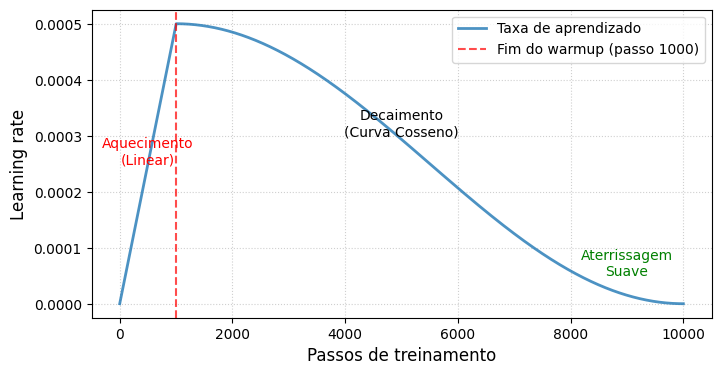

In [16]:
# simulando o agendador:
total_steps = 10000
warmup_steps = 1000
decay_steps = total_steps - warmup_steps
peak_lr = 5e-4

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=0.0, decay_steps=decay_steps,
                                                        warmup_target=peak_lr, warmup_steps=warmup_steps)

steps = np.arange(total_steps)
LRs = [lr_schedule(step).numpy() for step in steps]

plt.figure(figsize=(8, 4))
plt.plot(steps, LRs, label="Taxa de aprendizado", color="tab:blue", linewidth=2, alpha=0.8)
plt.axvline(x=warmup_steps, color="red", linestyle="--", alpha=0.7, label=f"Fim do warmup (passo {warmup_steps})")
plt.text(500, peak_lr*0.5, 'Aquecimento\n(Linear)', horizontalalignment='center', color='red')
plt.text(5000, peak_lr*0.6, 'Decaimento\n(Curva Cosseno)', horizontalalignment='center', color='black')
plt.text(9000, peak_lr*0.1, 'Aterrissagem\nSuave', horizontalalignment='center', color='green')
plt.xlabel("Passos de treinamento", fontsize=12)
plt.ylabel("Learning rate", fontsize=12)
plt.grid(linestyle=":", alpha=0.6)
plt.legend()
plt.show()

In [17]:
# warmup com decaimento de cosseno:
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=0.0, decay_steps=(total_steps - warmup_steps),
                                                        warmup_target=5e-4, warmup_steps=warmup_steps)

optimizer = optimizers.Adam(learning_rate=lr_schedule)

In [21]:
for epoch in range(1, n_epochs + 1):
    start_time = time.time()

    print(f"#Epoch {epoch}/{n_epochs}:")

    # métricas auxiliares para treino:
    train_loss_avg = tf.keras.metrics.Mean()
    train_acc_avg = tf.keras.metrics.Mean()

    # fase de treino:
    for step, (x_batch, y_batch) in enumerate(train_dset, start=1):

        # máscara de preenchimento booleana:
        pad_mask = (y_batch != eos_id)

        with tf.GradientTape() as tape:
            logits = model(x_batch, training=True)

            train_loss = loss_fun(y_batch, logits, pad_mask)

        # backpropagation:
        gradients = tape.gradient(train_loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        train_acc = acc_fun(y_batch, logits, pad_mask)

        train_loss_avg.update_state(train_loss)
        train_acc_avg.update_state(train_acc)

        print(f"Batch: {int(100*step/n_train)}% - Accuracy = {train_acc:.2f}", end='\r', flush=True)

    print()

    # métricas auxiliares para validação:
    val_loss_avg = tf.keras.metrics.Mean()
    val_acc_avg = tf.keras.metrics.Mean()

    # fase de validação:
    for x_batch_val, y_batch_val in val_dset:

        pad_mask = (y_batch_val != eos_id)

        logits_val = model(x_batch_val, training=False)

        val_loss = loss_fun(y_batch_val, logits_val, pad_mask)
        val_acc = acc_fun(y_batch_val, logits_val, pad_mask)

        val_loss_avg.update_state(val_loss)
        val_acc_avg.update_state(val_acc)

    print(f"Validation: Acc = {val_acc_avg.result().numpy():.2f} | Loss = {val_loss_avg.result().numpy():.4f}")
    print(f"Time taken: {time.time() - start_time:.2f}s\n")

    history["loss"].append(train_loss_avg.result().numpy())
    history["accuracy"].append(train_acc_avg.result().numpy())
    history["val_loss"].append(val_loss_avg.result().numpy())
    history["val_accuracy"].append(val_acc_avg.result().numpy())


#Epoch 1/3:

Validation: Acc = 0.00 | Loss = 10.8208
Time taken: 181.88s

#Epoch 2/3:

Validation: Acc = 0.00 | Loss = 10.8055
Time taken: 166.37s

#Epoch 3/3:

Validation: Acc = 0.00 | Loss = 10.7801
Time taken: 207.24s



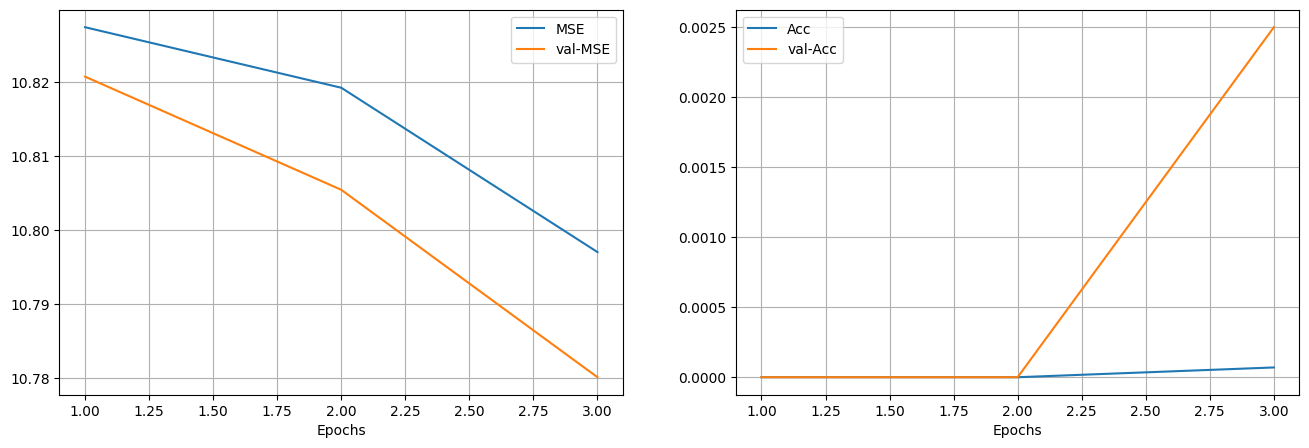

In [22]:
loss = history['loss']
acc = history['accuracy']

val_loss = history['val_loss']
val_acc = history['val_accuracy']

epochs = np.linspace(1, len(loss), len(loss))

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(epochs, loss, label='MSE')
ax[0].plot(epochs, val_loss, label='val-MSE')

ax[1].plot(epochs, acc, label='Acc')
ax[1].plot(epochs, val_acc, label='val-Acc')

for i in range(2):
    ax[i].set_xlabel("Epochs")
    ax[i].legend()
    ax[i].grid()

plt.show()

## **5. A inferência autoregressiva:**
<font size=3>

Agora, saímos do processamento em paralelo do treinamento do GPT e passamos para a inferência sequencial (autoregressiva).

### **5.1 Engenharia de amostragem:**
<font size=3>
    
Uma vez que extraímos os *logits* do último *token*, existem diferentes estratégias matemáticas que alteram drasticamente o comportamento de inferência do modelo:

* ***Greedy Search:*** Escolhe sempre o token com o maior *logit* absoluto ($\text{argmax}$). Embora seja rápido e determinístico, o modelo torna-se excessivamente rígido, caindo frequentemente em *loops* repetitivos de frases infinitas.

* **Temperatura ($T$):** É um hiperparâmetro de escala que divide os *logits* antes da aplicação do Softmax ($\text{logits} / T$).
    * Se $T \to 0$, os maiores *logits* tornam-se infinitamente superiores aos outros, colapsando a distribuição em uma busca *Greedy*.
    * Se $T = 1.0$, as probabilidades originais do modelo são mantidas.
    * Se $T > 1.0$, os *logits* são achatados, aumentando a entropia da distribuição. Isso dá chance a *tokens* menos prováveis de serem escolhidos, tornando o modelo altamente "criativo" (ou caótico, se o valor for muito alto).
    <br>

* ***Top-K Sampling:*** Filtra os *logits* para manter apenas os $K$ tokens mais prováveis da distribuição. O *score* de todos os outros *tokens* fora desse subconjunto é artificialmente definido como $-\infty$, impedindo que o modelo selecione palavras absurdas ou desconexas na cauda da distribuição probabilística.


In [23]:
def generate_text(prompt, model, tokenizer, max_new_tokens, temperature=0.7, top_k=5):

    # tokenização:
    prompt_ids = tokenizer.encode(prompt)
    generated_sequence = list(prompt_ids)

    for _ in range(max_new_tokens):
        # janela deslizante - restringe o contexto ao limite suportado pelo modelo (max_len):
        current_context = generated_sequence[-config['max_len']:]

        # ajustando o formato da entrada:
        input_tensor = tf.expand_dims(tf.constant(current_context, dtype=tf.int32), axis=0)

        # predição do modelo:
        logits = model(input_tensor, training=False)

        # capturando os logits do último token da sequência:
        last_token_logits = logits[0, -1, :]

        # aplicando a escala de temperatura:
        scaled_logits = last_token_logits/max(temperature, 1e-5)

        # filtrando os Top-K:
        if top_k > 0:
            top_values, _ = tf.math.top_k(scaled_logits, k=top_k)
            min_threshold = top_values[-1]

            top_k_mask = scaled_logits < min_threshold

            #penaliza os logits fora do top-k com -1e9 para que o Softmax os zere:
            filtered_logits = tf.where(top_k_mask, tf.constant(-1e9, dtype=tf.float32), scaled_logits)

        else:
            filtered_logits = scaled_logits

        # A função random.categorical aplica o Softmax internamente aos logits e realiza um sorteio.
        # Em vez de pegar sempre o token mais provável (argmax), ele sorteia o próximo ID dando mais
        # chance aos logits maiores, garantindo a criatividade.
        next_token_id = tf.random.categorical(tf.expand_dims(filtered_logits, axis=0), num_samples=1)
        next_token_id = int(next_token_id[0, 0].numpy())

        # concatenando o token gerado com a sequência:
        generated_sequence.append(next_token_id)

    # decodificando a lista final de IDs de volta para uma string:
    return tokenizer.decode(generated_sequence, skip_special_tokens=True)




In [24]:
prompt = "Do you like to"

result = generate_text(prompt, model, tokenizer,  max_new_tokens=3, temperature=0.9, top_k=3)

print(result)

Do you like to weldingghan ambush


## **6. Discussões finais:**

### **6.1 As Leis de Escala:**
<font size=3>
    
Ao longo deste notebook, nós construímos e treinamos um modelo GPT em uma escala laboratorial extremamente reduzida (poucas camadas, *embeddings* pequenos e dados sintéticos). No entanto, a arquitetura matemática subjacente é rigorosamente idêntica à dos modelos de escala comercial. A pergunta que naturalmente surge é: *o que acontece quando expandimos esses números para proporções massivas?*

Em 2020, os pesquisadores publicaram um estudo entitulado [***Scaling Laws for Neural Language Models***](https://arxiv.org/pdf/2001.08361v1). Eles demonstraram que o desempenho de um modelo de linguagem causal (medido pela perda de entropia cruzada em dados de teste) segue uma **lei de potência** previsível e está rigidamente acoplado a três fatores:
1. **O número de parâmetros treináveis ($N$)** (excluindo os *embeddings*).
2. **O tamanho do *dataset* de treinamento ($D$)** em número de *tokens*.
3. **A quantidade total de computação ($C$)** alocada para o treino (o número absoluto de operações matemáticas que os processadores precisam realizar para ler todos os dados e treinar o modelo do primeiro ao último segundo).

O aspecto mais fascinante dessa descoberta é que o ganho de desempenho não é prejudicado à medida que o modelo cresce. Se aumentarmos $N$, $D$ e $C$ de forma equilibrada, **o erro do modelo continua caindo de forma previsível por ordens de magnitude**. É por essa razão que a indústria migrou do GPT-2 (1.5 bilhão de parâmetros) para o GPT-3 (175 bilhões) e além.


### **6.2 Habilidades Emergentes:**
<font size=3>
    
Uma habilidade é considerada emergente se ela não está presente em modelos menores, mas aparece subitamente quando o modelo atinge um determinado limiar crítico de escala (seja em número de parâmetros ou em computação).
    
Enquanto um modelo com 1 bilhão de parâmetros performa próximo ao acaso em tarefas complexas, um modelo com 100 bilhões de parâmetros, usando exatamente o mesmo código que implementamos nesta aula, adquire repentinamente a capacidade de:

* **Aprendizado com Poucas Demonstrações (*few-shot learning*):** Resolver problemas matemáticos inéditos apenas recebendo 2 ou 3 exemplos de perguntas e respostas dentro do próprio *prompt*, sem nenhuma atualização de pesos via *backpropagation*.

* **Raciocínio Lógico encadeado (*xhain-of-thought*):** Desmembrar uma instrução complexa em subetapas lógicas antes de responder.

* **Geração de código estruturado:** Compreender a sintaxe de linguagens de programação e traduzir requisitos em linguagem natural para código funcional (Python, C++, SQL).

Essas habilidades não foram programadas explicitamente. Elas emergiram como uma propriedade sistêmica do modelo ao tentar resolver o objetivo matemático fundamental: **prever o próximo token da forma mais precisa possível**.


## **Referências:**
<font size=3>

- Bahree, Amit. *Generative AI in Action*. Manning, 2024.
- Raschka, Sebastian. *Build a Large Language Model*. Manning, 2025.
  